In [4]:
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')  
import yfinance as yf 
import matplotlib.pyplot as plt 

from model import Asset, Portfolio
from view import Viewer 

In [5]:
# Construct a portfolio by creating objects from the Assets class, and then adding them to the Portfolio class using the add_asset() method.
apple = Asset("AAPL", "Technology", "Equity", 10, 150)
microsoft = Asset("MSFT", "Technology", "Equity", 5, 300)
nflx = Asset("NFLX", "Entertainment", "Equity", 3, 33.38)

portfolio = Portfolio()

portfolio.add_asset(apple)
portfolio.add_asset(microsoft)
portfolio.add_asset(nflx)


Display a portfolio overview using .portfolio_table()

In [6]:
portfolio.portfolio_table()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Ticker,Sector,Asset Class,Quantity,Purchase Price,Current Price,Transaction Value,Current Value,P/L,Weight
0,AAPL,Technology,Equity,10,150.00,270.230011,1500.00,2702.300110,1202.300110,0.529014
1,MSFT,Technology,Equity,5,300.00,422.790009,1500.00,2113.950043,613.950043,0.413836
2,NFLX,Entertainment,Equity,3,33.38,97.309998,100.14,291.929993,191.789993,0.057150


Optionally a reformed table grouped by a sector

In [7]:
portfolio.groupby_table('Sector')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Sector,Transaction Value,Current Value,P/L,Weight
0,Entertainment,100.14,291.929993,191.789993,0.05715
1,Technology,3000.00,4816.250153,1816.250153,0.94285


In [8]:
simulated_portfolio_returns, simulated_value_paths = portfolio.simulate(start='2024-01-01', 
                                                                        end = '2026-04-20',
                                                                        method="Bootstrap",
                                                                        paths = 10_000, 
                                                                        len_simulations = 252*15,
                                                                        seed_value = 10, 
                                                                        block_size=20)

portfolio.simulation_metrics(simulated_portfolio_returns, simulated_value_paths)

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Value
Mean Final Value,6.553248e+04
Median Final Value,4.614989e+04
Mean Cumulative Return,1.182893e+01
Median Cumulative Return,8.034507e+00
Mean Annual Return,1.601743e-01
Mean Annual Volatility,2.145807e-01
Mean Sharpe Ratio,7.448984e-01
5% VaR Return,-2.065644e-02
5% Expected Shortfall Return,-3.014270e-02
Probability of Loss,4.000000e-03


Viewer Functionality: 

[*********************100%***********************]  3 of 3 completed


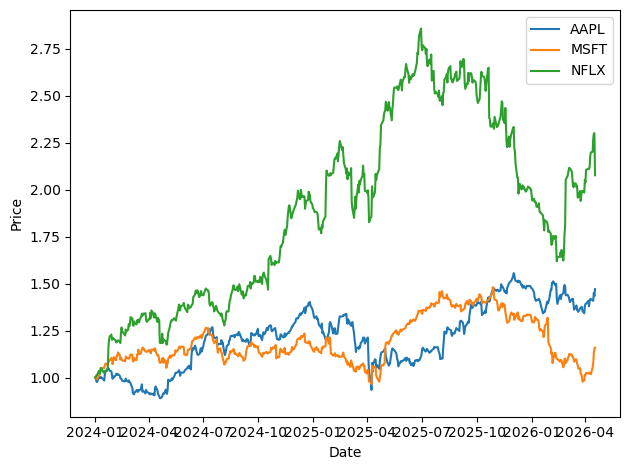

[*********************100%***********************]  1 of 1 completed


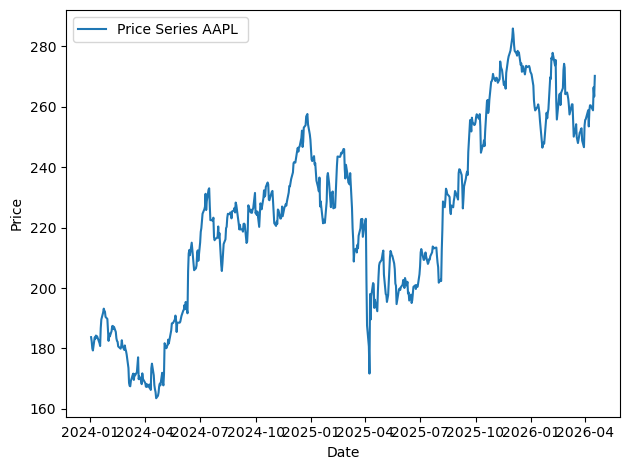

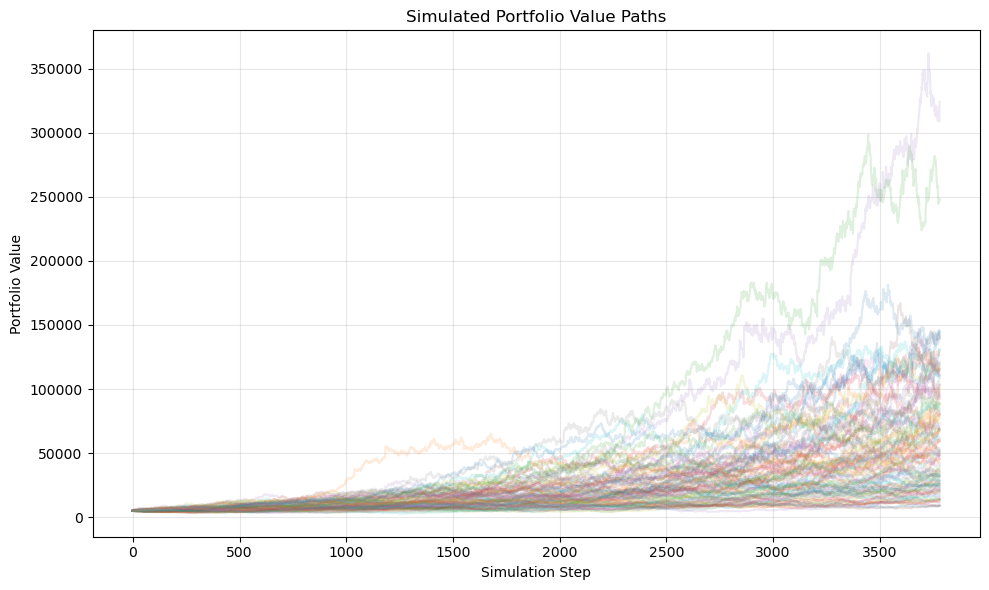

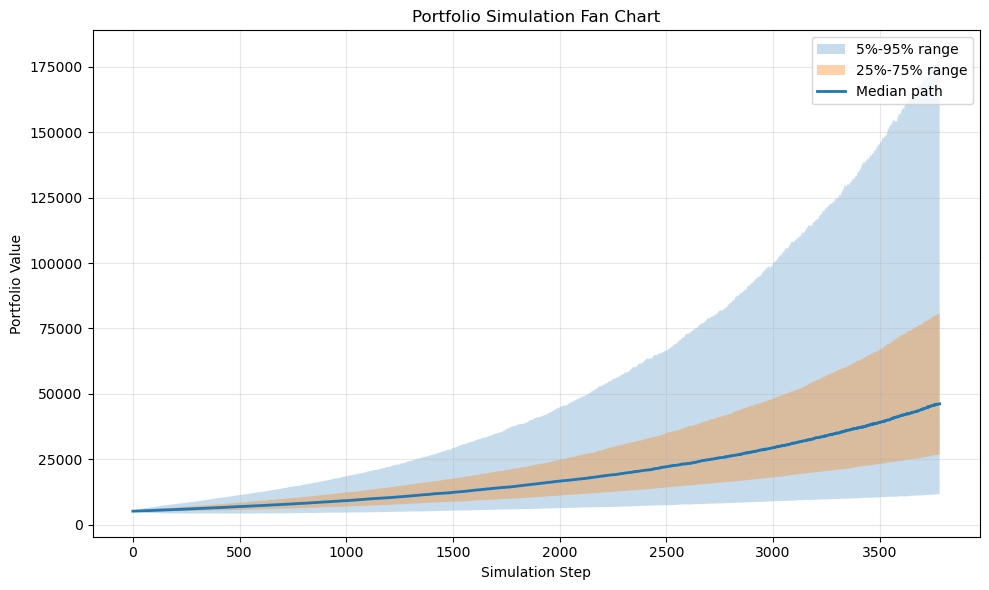

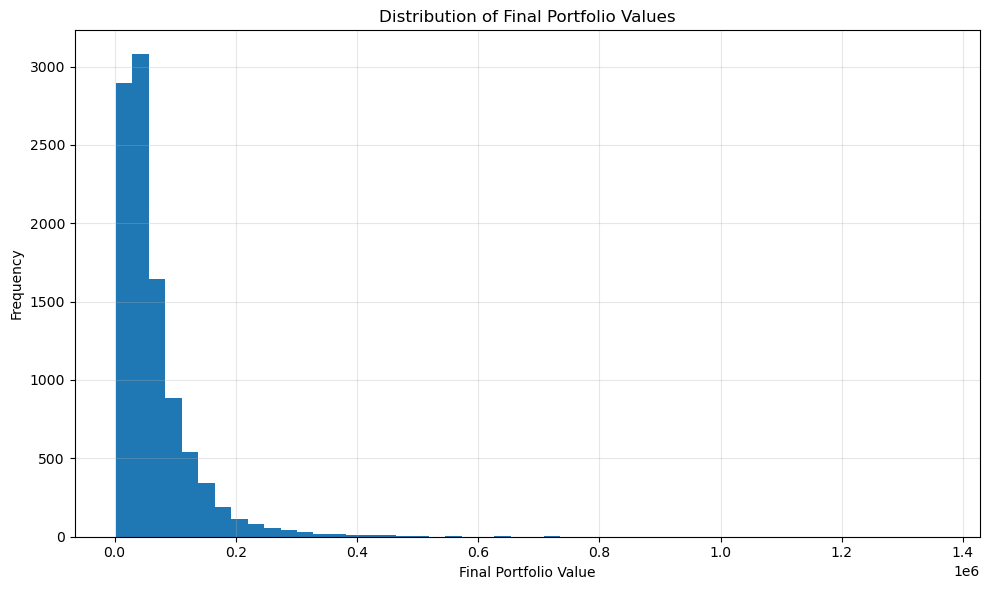

In [9]:
viewer = Viewer() 
viewer.plot_prices(portfolio, normalized = True) 
viewer.plot_prices(apple)
viewer.plot_simulation_paths(simulated_value_paths, n_paths=100)
viewer.plot_simulation_fan_chart(simulated_value_paths)
viewer.plot_final_value_distribution(simulated_value_paths)